LIBRARY

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler, MinMaxScaler

GATHERING DATA

In [2]:
# Load dataset
df = pd.read_csv('http://raw.githubusercontent.com/ekasaaa/analisis-dataset-gizi/refs/heads/main/preprocessed_dataset.csv')
df.head()

,Unnamed: 0,Nama,Kategori,Jumlah Porsi,Takaran Porsi,Kalori (kal),Lemak (g),Lemak Jenuh (g),Lemak Tak Jenuh Ganda (g),Lemak Tak Jenuh Tunggal (g),Kolestrol (g),Protein (g),Karbohidrat (g),Serat (g),Gula (g),Sodium (g),Kalium (g)
0,0,Alpukat,Buah Buahan,100,gram (g),160.0,14.66,2.126,1.816,9.799,0.0,2.00,8.53,6.7,0.66,7.0,485.0
1,1,Guacamole,Buah Buahan,1,sdm,23.0,2.08,0.302,0.258,1.393,0.0,0.29,1.24,1.0,0.10,22.0,69.0
2,2,Guacamole dengan Tomat,Buah Buahan,100,gram (g),116.0,9.94,1.446,1.258,6.625,0.0,1.62,7.64,4.9,1.37,201.0,393.0
3,3,Guacamole dengan Tomat dan Cabe Paprika,Buah Buahan,1,mangkok,266.0,22.72,3.304,2.882,15.129,0.0,3.77,17.75,11.4,3.31,459.0,913.0
4,4,Buah Anggur,Buah Buahan,1,tanpa biji,3.0,0.01,0.003,0.002,0.000,0.0,0.04,0.90,0.0,0.77,0.0,10.0


ASSESSING DATA

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 392 entries, 0 to 391
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Unnamed: 0                   392 non-null    int64  
 1   Nama                         392 non-null    object 
 2   Kategori                     392 non-null    object 
 3   Jumlah Porsi                 392 non-null    int64  
 4   Takaran Porsi                392 non-null    object 
 5   Kalori (kal)                 392 non-null    float64
 6   Lemak (g)                    392 non-null    float64
 7   Lemak Jenuh (g)              392 non-null    float64
 8   Lemak Tak Jenuh Ganda (g)    392 non-null    float64
 9   Lemak Tak Jenuh Tunggal (g)  392 non-null    float64
 10  Kolestrol (g)                392 non-null    float64
 11  Protein (g)                  392 non-null    float64
 12  Karbohidrat (g)              392 non-null    float64
 13  Serat (g)           

In [4]:
#Mengecek missing values pada dataset makanan anak

df.isna().sum()

Unnamed: 0                     0
Nama                           0
Kategori                       0
Jumlah Porsi                   0
Takaran Porsi                  0
Kalori (kal)                   0
Lemak (g)                      0
Lemak Jenuh (g)                0
Lemak Tak Jenuh Ganda (g)      0
Lemak Tak Jenuh Tunggal (g)    0
Kolestrol (g)                  0
Protein (g)                    0
Karbohidrat (g)                0
Serat (g)                      0
Gula (g)                       0
Sodium (g)                     0
Kalium (g)                     0
dtype: int64

In [5]:
#Mengecek duplikasi tabel df

print("Jumlah duplikasi: ", df.duplicated().sum())

Jumlah duplikasi:  0


In [6]:
#Mengecek menggunakan method describe

df.describe()

,Unnamed: 0,Jumlah Porsi,Kalori (kal),Lemak (g),Lemak Jenuh (g),Lemak Tak Jenuh Ganda (g),Lemak Tak Jenuh Tunggal (g),Kolestrol (g),Protein (g),Karbohidrat (g),Serat (g),Gula (g),Sodium (g),Kalium (g)
count,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000
mean,200.619898,60.117347,115.135204,4.513036,1.594901,0.743388,1.576679,27.736821,7.379974,11.780663,3.237755,4.817041,224.307806,243.438776
std,116.724481,48.598480,103.052514,7.186352,3.933808,1.395391,2.548437,54.463439,8.762099,16.060288,9.950697,10.344179,305.736756,238.418857
min,0.000000,1.000000,2.000000,0.010000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,100.750000,1.000000,42.000000,0.237500,0.038750,0.065750,0.026750,0.000000,1.045000,0.675000,0.000000,0.047500,6.000000,79.500000
50%,200.500000,100.000000,86.000000,1.370000,0.356000,0.259500,0.303000,0.000000,3.135000,6.145000,1.100000,1.145000,81.500000,206.000000
75%,302.250000,100.000000,149.250000,5.935000,1.666250,0.926750,2.124250,31.000000,10.957500,16.817500,2.700000,4.205000,344.250000,320.250000
max,400.000000,100.000000,660.000000,64.530000,57.218000,12.170000,15.129000,400.000000,35.750000,82.360000,83.000000,65.000000,1887.000000,1744.000000


CLEANING DATA

In [ ]:
# Menghapus kolom index tidak penting
df = df.drop(columns=['Unnamed: 0'])

In [ ]:
#cek
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 392 entries, 0 to 391
Data columns (total 16 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Nama                         392 non-null    object 
 1   Kategori                     392 non-null    object 
 2   Jumlah Porsi                 392 non-null    int64  
 3   Takaran Porsi                392 non-null    object 
 4   Kalori (kal)                 392 non-null    float64
 5   Lemak (g)                    392 non-null    float64
 6   Lemak Jenuh (g)              392 non-null    float64
 7   Lemak Tak Jenuh Ganda (g)    392 non-null    float64
 8   Lemak Tak Jenuh Tunggal (g)  392 non-null    float64
 9   Kolestrol (g)                392 non-null    float64
 10  Protein (g)                  392 non-null    float64
 11  Karbohidrat (g)              392 non-null    float64
 12  Serat (g)                    392 non-null    float64
 13  Gula (g)            

In [ ]:
# Kolom numerik
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Kolom kategorikal
categorical_cols = df.select_dtypes(include=['object']).columns

print("Kolom Numerik:")
print(numeric_cols)

print("\nKolom Kategorikal:")
print(categorical_cols)

Kolom Numerik:
Index(['Jumlah Porsi', 'Kalori (kal)', 'Lemak (g)', 'Lemak Jenuh (g)',
       'Lemak Tak Jenuh Ganda (g)', 'Lemak Tak Jenuh Tunggal (g)',
       'Kolestrol (g)', 'Protein (g)', 'Karbohidrat (g)', 'Serat (g)',
       'Gula (g)', 'Sodium (g)', 'Kalium (g)'],
      dtype='object')

Kolom Kategorikal:
Index(['Nama', 'Kategori', 'Takaran Porsi'], dtype='object')


In [ ]:
#Mengecek missing values pada dataset makanan anak

df.isna().sum()

Nama                           0
Kategori                       0
Jumlah Porsi                   0
Takaran Porsi                  0
Kalori (kal)                   0
Lemak (g)                      0
Lemak Jenuh (g)                0
Lemak Tak Jenuh Ganda (g)      0
Lemak Tak Jenuh Tunggal (g)    0
Kolestrol (g)                  0
Protein (g)                    0
Karbohidrat (g)                0
Serat (g)                      0
Gula (g)                       0
Sodium (g)                     0
Kalium (g)                     0
dtype: int64

In [ ]:
#Mengecek duplikasi tabel df

print("Jumlah duplikasi: ", df.duplicated().sum())

Jumlah duplikasi:  0


HANDLING OUTLIER

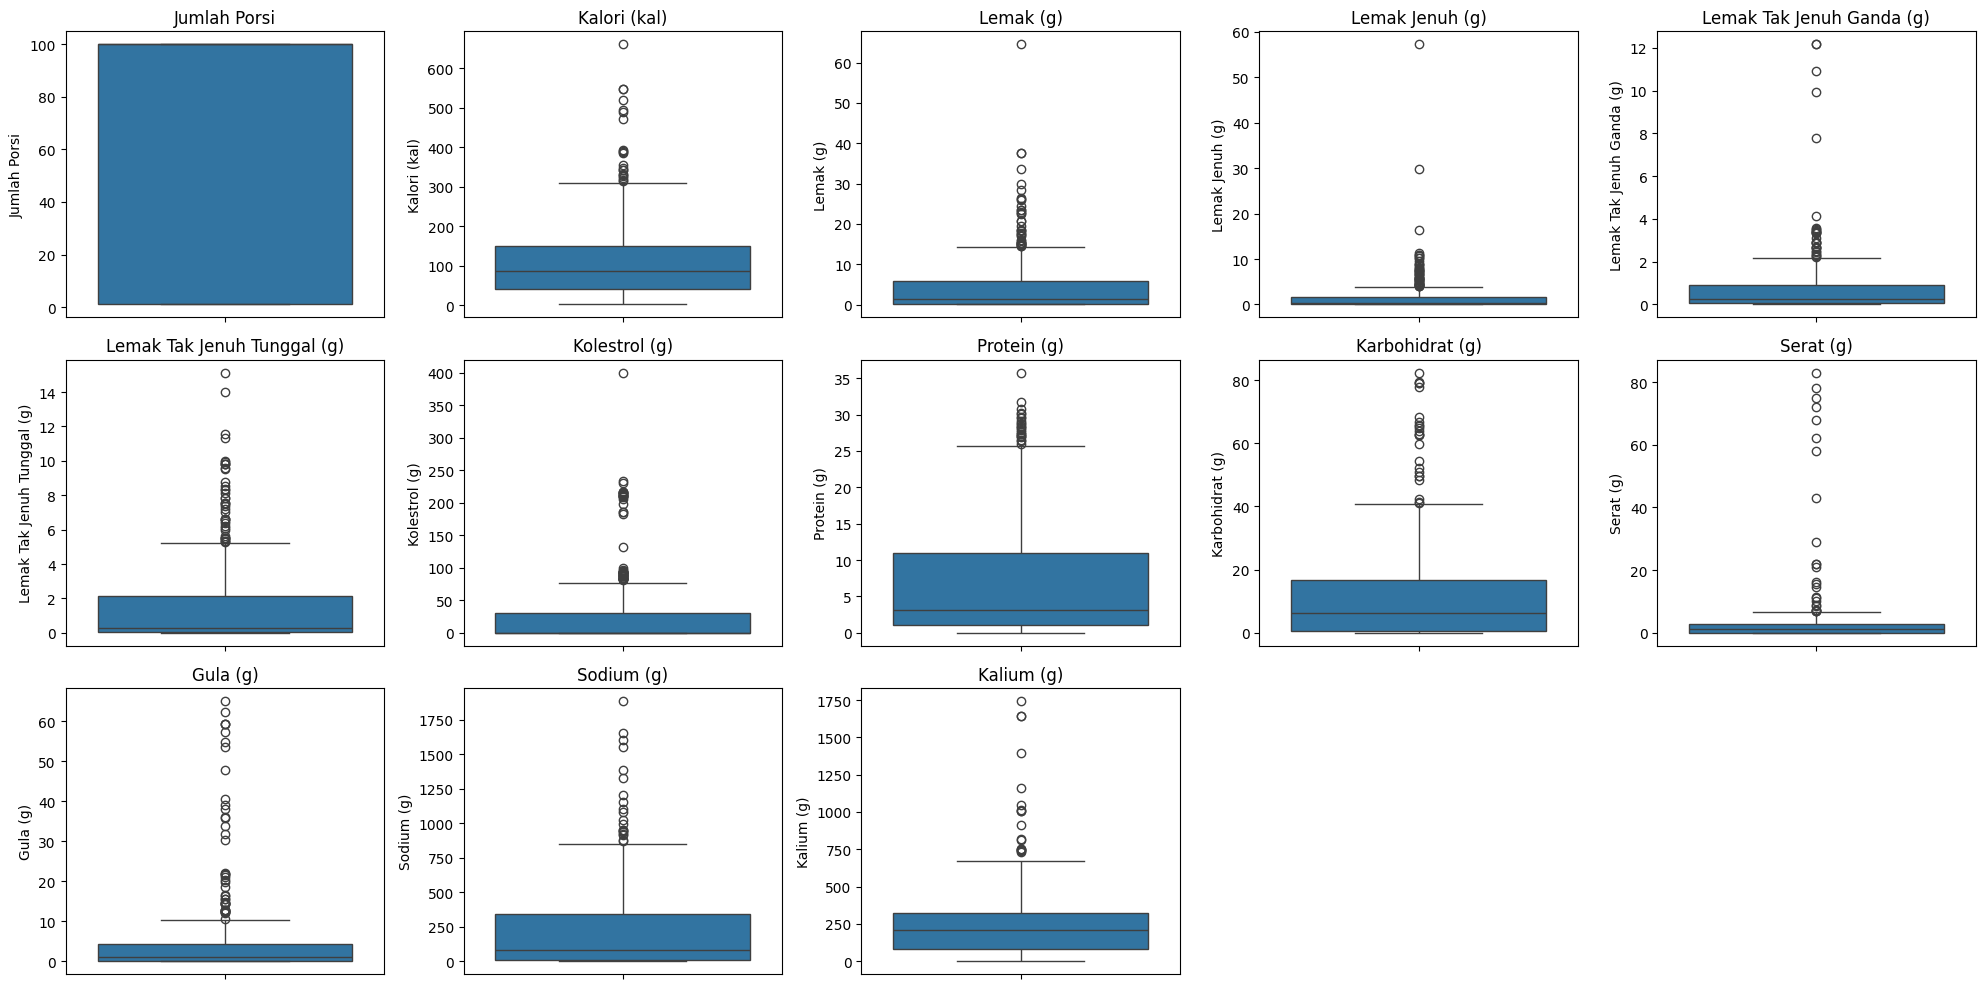

In [ ]:
plt.figure(figsize=(20,10))

for i, col in enumerate(numeric_cols):
    
    plt.subplot(3,5,i+1)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [ ]:
# IDENTIFIKASI OUTLIER (TANPA MENGHAPUS DATA)
outlier_summary = []

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    ]

    outlier_summary.append({
        'Kolom': col,
        'Jumlah Outlier': len(outliers)
    })

outlier_df = pd.DataFrame(outlier_summary)
outlier_df

,Kolom,Jumlah Outlier
0,Jumlah Porsi,0
1,Kalori (kal),21
2,Lemak (g),36
3,Lemak Jenuh (g),46
4,Lemak Tak Jenuh Ganda (g),29
5,Lemak Tak Jenuh Tunggal (g),40
6,Kolestrol (g),53
7,Protein (g),23
8,Karbohidrat (g),24
9,Serat (g),25


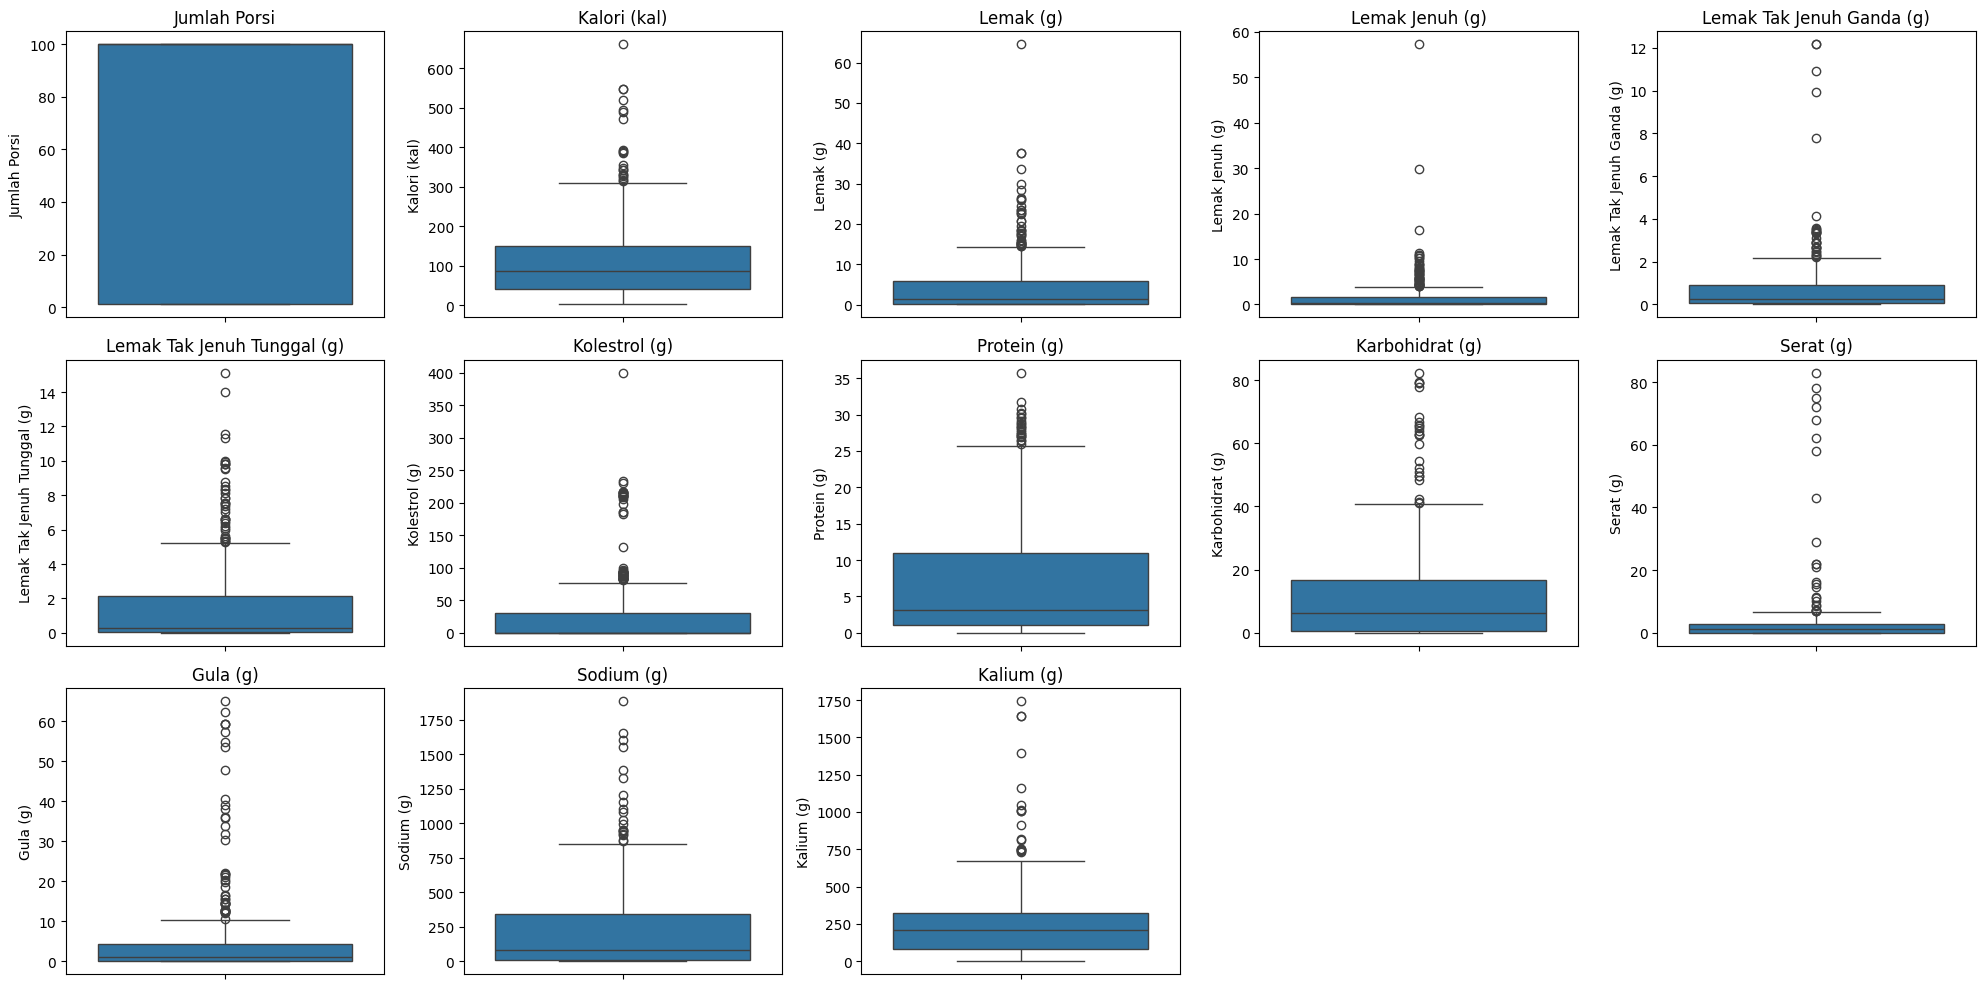

In [ ]:
plt.figure(figsize=(20,10))

for i, col in enumerate(numeric_cols):

    plt.subplot(3,5,i+1)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

SCALED

In [ ]:
# scaler
scaler = MinMaxScaler()

# copy dataset
df = df.copy()

# scaling
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

In [ ]:
df.describe()

,Jumlah Porsi,Kalori (kal),Lemak (g),Lemak Jenuh (g),Lemak Tak Jenuh Ganda (g),Lemak Tak Jenuh Tunggal (g),Kolestrol (g),Protein (g),Karbohidrat (g),Serat (g),Gula (g),Sodium (g),Kalium (g)
count,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000
mean,0.597145,0.171938,0.069793,0.027874,0.061084,0.104216,0.069342,0.206433,0.143039,0.039009,0.074108,0.118870,0.139586
std,0.490894,0.156615,0.111382,0.068751,0.114658,0.168447,0.136159,0.245094,0.195001,0.119888,0.159141,0.162023,0.136708
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.060790,0.003526,0.000677,0.005403,0.001768,0.000000,0.029231,0.008196,0.000000,0.000731,0.003180,0.045585
50%,1.000000,0.127660,0.021079,0.006222,0.021323,0.020028,0.000000,0.087692,0.074611,0.013253,0.017615,0.043190,0.118119
75%,1.000000,0.223784,0.091832,0.029121,0.076150,0.140409,0.077500,0.306503,0.204195,0.032530,0.064692,0.182432,0.183630
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
df.to_csv('dataset_final_scaledminmax.csv', index=False)

PENJELASAN:

Pada tahap preprocessing, dilakukan proses normalisasi data menggunakan metode MinMaxScaler. Tujuan dari scaling ini adalah untuk menyamakan rentang nilai pada setiap fitur numerik agar berada pada skala yang sama, yaitu antara 0 hingga 1. Dengan demikian, perbedaan skala antar atribut tidak mempengaruhi performa model machine learning yang akan digunakan pada tahap selanjutnya.

Setelah proses scaling dilakukan, seluruh fitur numerik seperti kalori, lemak, protein, karbohidrat, sodium, dan kalium berhasil ditransformasikan ke dalam rentang nilai 0–1. Hasil ini menunjukkan bahwa proses normalisasi berjalan dengan baik dan data telah siap digunakan untuk proses pemodelan.